Simulation examples for validation chapter


In [1]:
import time
import pymc as pm
import arviz as az
from scipy.stats import (
    norm, lognorm, uniform, cauchy, 
    poisson, nbinom, bernoulli,
    binom
)
from scipy.optimize import minimize

from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

IMAGE_DIR = Path('../../book/book/images')

In [2]:
sample_size = 1000

# set up numpy random state
random_state = np.random.default_rng(42)

# True population parameters (using standard normal)
true_mean = 0
true_sd = 1

# take sample
normal_samples = norm.rvs(loc=true_mean, scale=true_sd, size=sample_size, random_state=random_state)

# pop sd is the standard deviation of the entire population (ddof=0)
pop_sd = np.std(normal_samples, ddof=0)

sample_sd = np.std(normal_samples)
sample_mean = np.mean(normal_samples)


In [3]:
# compute confidence interval using t distribution
from scipy.stats import t

# Calculate 95% confidence interval
confidence_level = 0.95
alpha = 1 - confidence_level
degrees_of_freedom = sample_size - 1

# Get the critical t-value
t_critical = t.ppf(1 - alpha/2, degrees_of_freedom)

# Calculate standard error
standard_error = sample_sd / np.sqrt(sample_size)

# Calculate margin of error
margin_of_error = t_critical * standard_error

# Calculate confidence interval
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print(f"Sample mean: {sample_mean:.5f}")
print(f"Sample SD: {sample_sd:.5f}")
print(f"Standard error: {standard_error:.5f}")
print(f"t-critical value (df={degrees_of_freedom}): {t_critical:.5f}")
print(f"95% Confidence Interval: [{ci_lower:.5f}, {ci_upper:.5f}]")

Sample mean: -0.02889
Sample SD: 0.98872
Standard error: 0.03127
t-critical value (df=999): 1.96234
95% Confidence Interval: [-0.09025, 0.03246]


### Bayesian estimation

In [4]:


start_time = time.time()

# Bayesian estimation using PyMC
with pm.Model() as model:
    # Priors for unknown model parameters
    mu = pm.Normal('mu', mu=0, sigma=1000)  # Prior for mean
    sigma = pm.HalfNormal('sigma', sigma=100)  # Prior for standard deviation (must be positive)
    
    # Likelihood (sampling distribution) of observations
    likelihood = pm.Normal('likelihood', mu=mu, sigma=sigma, observed=normal_samples)
    
    # Posterior sampling
    trace = pm.sample(10000, tune=1000, return_inferencedata=True, random_seed=42)

# Extract posterior estimates
posterior_mean = trace.posterior['mu'].mean().values
posterior_sd = trace.posterior['sigma'].mean().values

# extract highest density interval
hdi = az.hdi(trace, hdi_prob=0.95)
hdi_values = hdi.mu.values

elapsed_time_bayes = time.time() - start_time

print(trace)
print(f"Bayesian estimation time: {elapsed_time_bayes:.4f} seconds")
#print(f'Bayesian time versus optimization: {elapsed_time_bayes/elapsed_time_opt:.4f} times slower')
#print(f'Bayesian time versus grid search: {elapsed_time_bayes/elapsed_time_grid:.4f} times slower')
print(f"Posterior mean: {posterior_mean:.5f}, Posterior sd: {posterior_sd:.5f}")
print(f"Sample mean: {sample_mean:.5f}, Sample sd: {sample_sd:.5f}")
print(f'95% HDI values: {hdi_values}')
print(f'95% CI based on t-distribution: [{ci_lower:.5f}, {ci_upper:.5f}]')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 1 seconds.


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
Bayesian estimation time: 2.0103 seconds
Posterior mean: -0.02895, Posterior sd: 0.99033
Sample mean: -0.02889, Sample sd: 0.98872
95% HDI values: [-0.08993754  0.03335397]
95% CI based on t-distribution: [-0.09025, 0.03246]


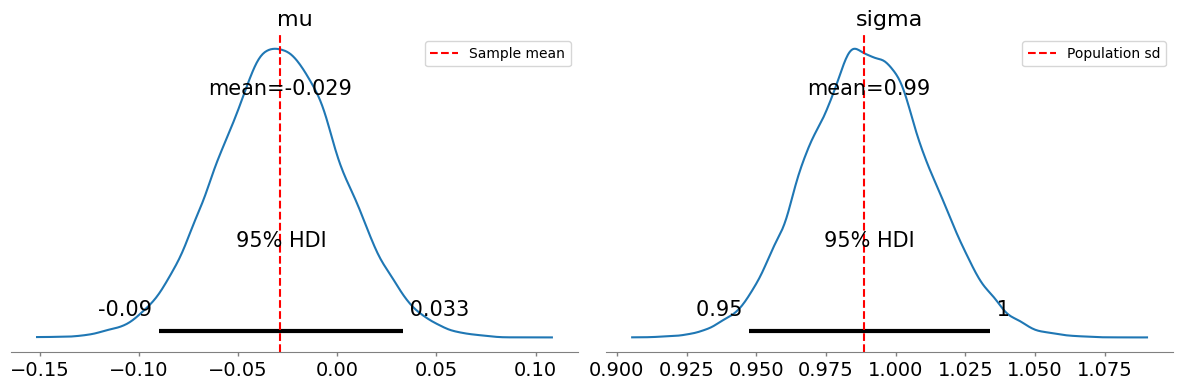

In [5]:
# Visualize posterior distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot posterior for mu
az.plot_posterior(trace, var_names=['mu'], ax=axes[0], hdi_prob=0.95)
axes[0].axvline(sample_mean, color='red', linestyle='--', label='Sample mean')
axes[0].legend()

# Plot posterior for sigma
az.plot_posterior(trace, var_names=['sigma'], ax=axes[1], hdi_prob=0.95)
axes[1].axvline(sample_sd, color='red', linestyle='--', label='Population sd')
axes[1].legend()

plt.tight_layout()
plt.savefig(IMAGE_DIR / 'bayesian_posterior.png', dpi=150, bbox_inches='tight')
plt.show()
